<a href="https://colab.research.google.com/github/siva11217/SivaEDAProject/blob/main/23BDS0156__P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME : M.SIVA CHARAN REDDY

REG.NO : 23BDS0156


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Suicide%20data.csv"
df = pd.read_csv(url)

df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [4]:
df.info()

df.describe()

df.describe(include='all')

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population',
       'suicides/100k pop', 'country-year', 'HDI for year',
       ' gdp_for_year ($) ', 'gdp_per_capita ($)', 'generation'],
      dtype='object')

In [5]:
df.isnull().sum()

df = df.drop_duplicates()

df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1206/4038495577.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [6]:
df.columns = df.columns.str.strip()

print(df.dtypes)

country                object
year                    int64
sex                    object
age                    object
suicides_no             int64
population              int64
suicides/100k pop     float64
country-year           object
HDI for year          float64
gdp_for_year ($)       object
gdp_per_capita ($)      int64
generation             object
dtype: object


In [7]:
if 'sex' in df.columns:
    df['sex'] = df['sex'].astype('category')

if 'country' in df.columns:
    df['country'] = df['country'].astype('category')

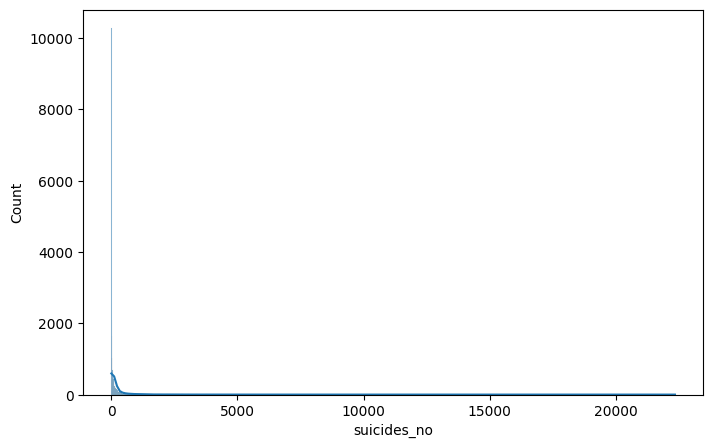

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['suicides_no'], kde=True)
plt.show()

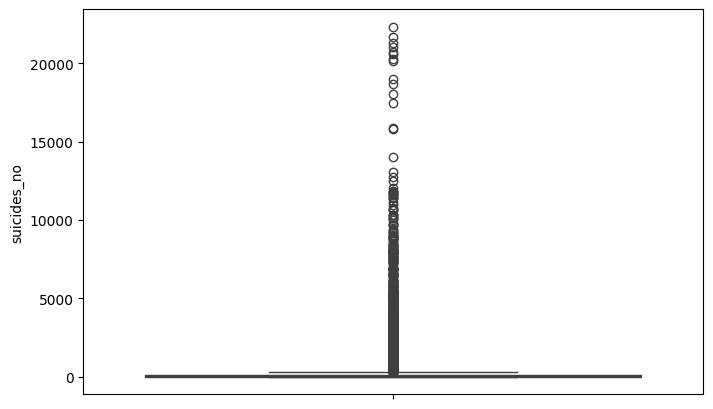

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['suicides_no'])
plt.show()

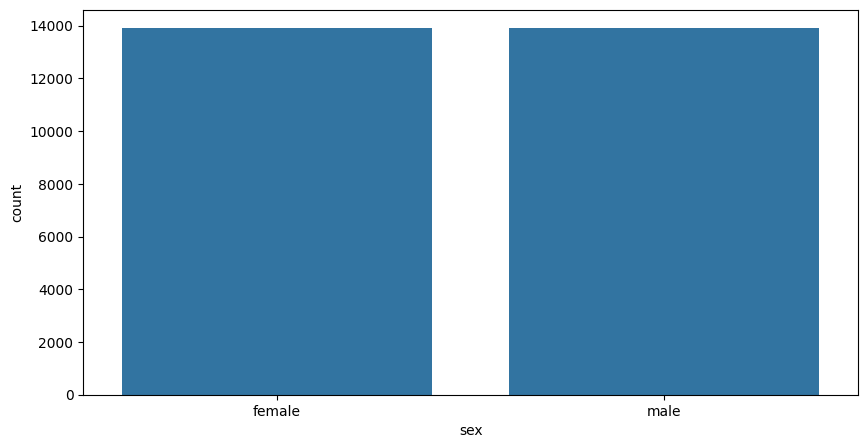

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='sex', data=df)
plt.show()

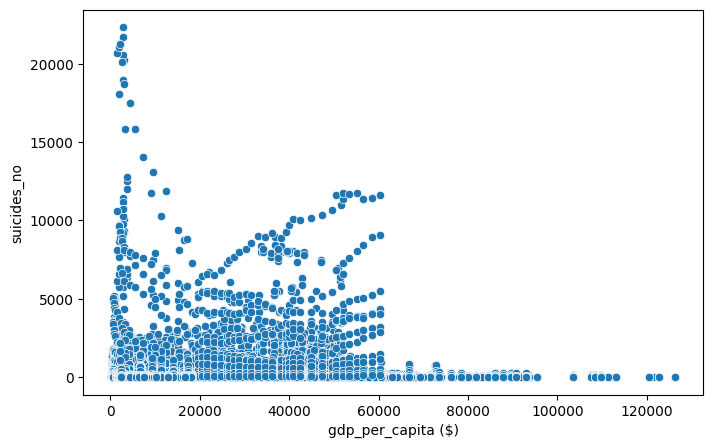

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='gdp_per_capita ($)', y='suicides_no', data=df)
plt.show()

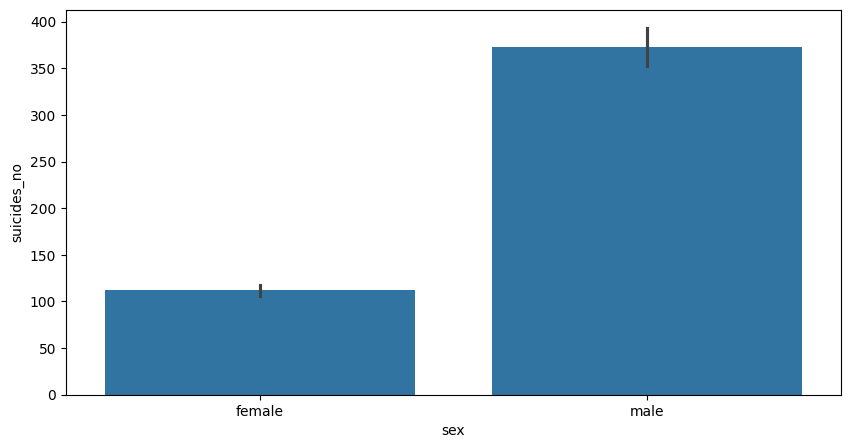

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(x='sex', y='suicides_no', data=df)
plt.show()

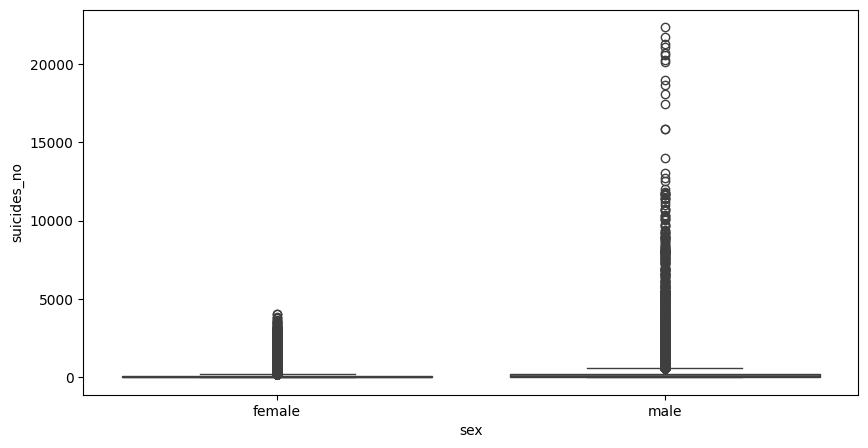

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x='sex', y='suicides_no', data=df)
plt.show()

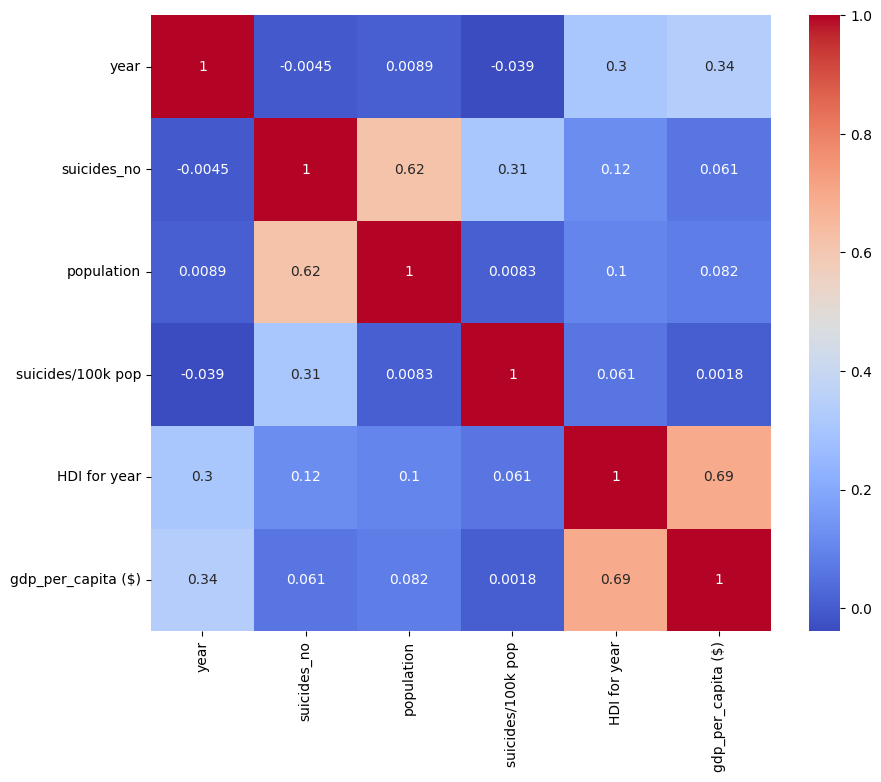

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

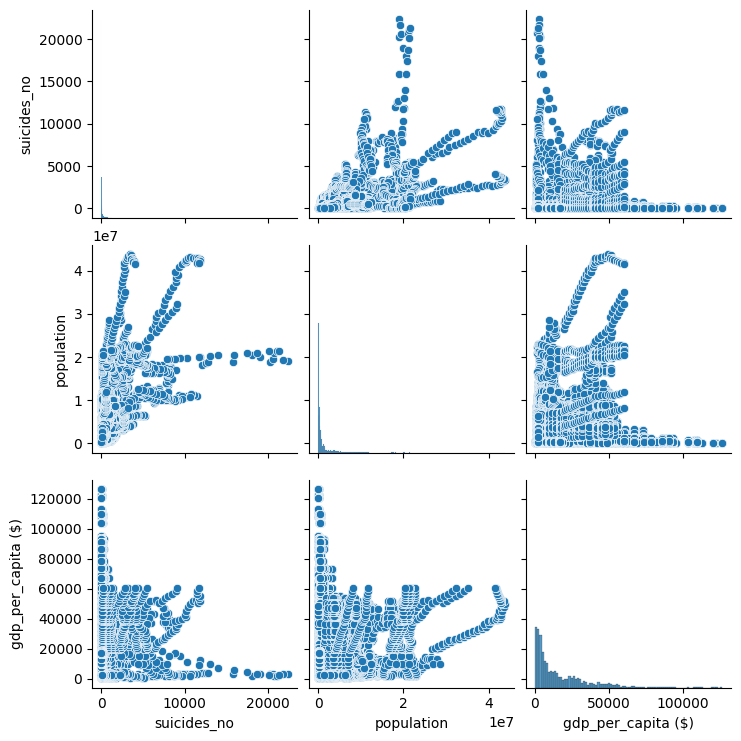

In [15]:
sns.pairplot(df[['suicides_no','population','gdp_per_capita ($)']])
plt.show()

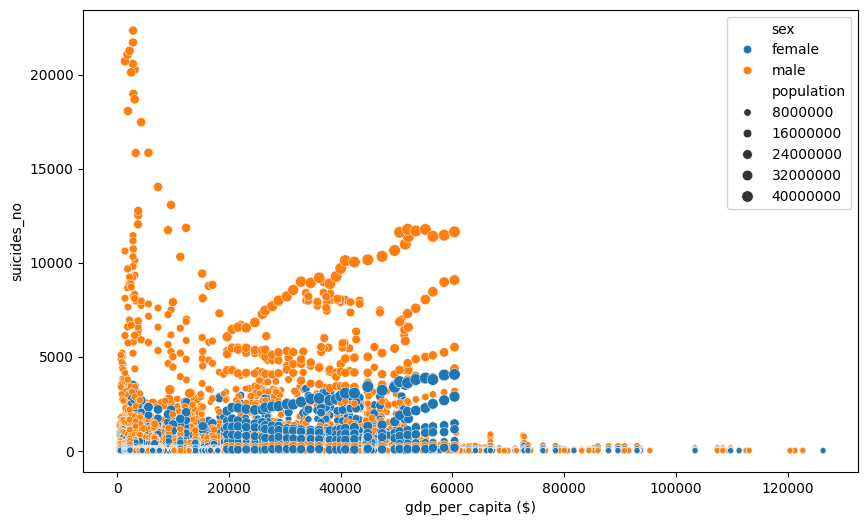

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='gdp_per_capita ($)',
    y='suicides_no',
    size='population',
    hue='sex',
    data=df
)
plt.show()

In [17]:
# PHASE II

## 1D, 2D and 3D Statistical Analysis

## K-Means Clustering

## Hierarchical Clustering

In [18]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(27820, 12)
Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population',
       'suicides/100k pop', 'country-year', 'HDI for year', 'gdp_for_year ($)',
       'gdp_per_capita ($)', 'generation'],
      dtype='object')
   country  year     sex          age  suicides_no  population  \
0  Albania  1987    male  15-24 years           21      312900   
1  Albania  1987    male  35-54 years           16      308000   
2  Albania  1987  female  15-24 years           14      289700   
3  Albania  1987    male    75+ years            1       21800   
4  Albania  1987    male  25-34 years            9      274300   

   suicides/100k pop country-year  HDI for year gdp_for_year ($)  \
0               6.71  Albania1987           NaN    2,156,624,900   
1               5.19  Albania1987           NaN    2,156,624,900   
2               4.83  Albania1987           NaN    2,156,624,900   
3               4.59  Albania1987           NaN    2,156,624,900   
4               3.28  Albania1987   

In [19]:
## 1D Statistical Analysis

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())


 year
Mean: 2001.2583752695903
Median: 2002.0
Variance: 71.72489300702198
Standard Deviation: 8.469055024441746

 suicides_no
Mean: 242.57440690150972
Median: 25.0
Variance: 813690.4442639275
Standard Deviation: 902.04791683365

 population
Mean: 1844793.6173975556
Median: 430150.0
Variance: 15302018400947.766
Standard Deviation: 3911779.4417563686

 suicides/100k pop
Mean: 12.816097411933864
Median: 5.99
Variance: 359.53889995312005
Standard Deviation: 18.96151101450304

 HDI for year
Mean: 0.7618453942626495
Median: 0.766
Variance: 0.008429606326500217
Standard Deviation: 0.09181288758393462

 gdp_per_capita ($)
Mean: 16866.464414090584
Median: 9372.0
Variance: 356740544.99342066
Standard Deviation: 18887.57647220576


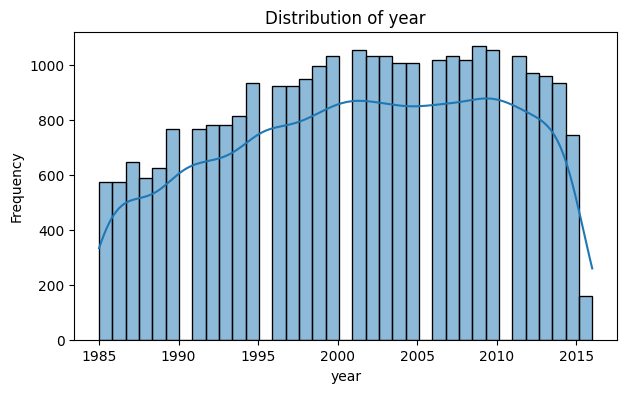

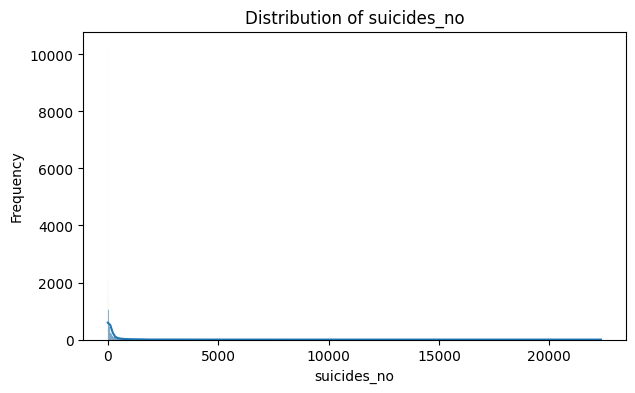

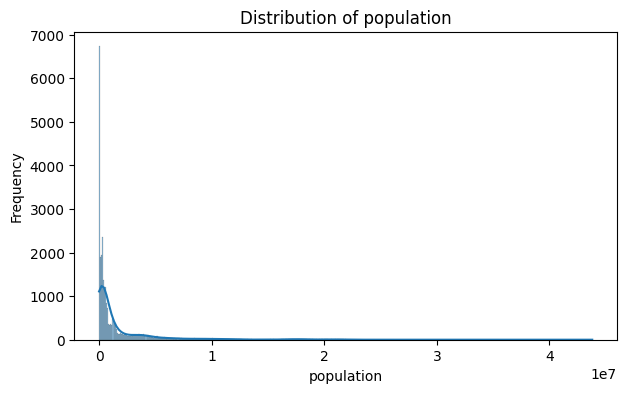

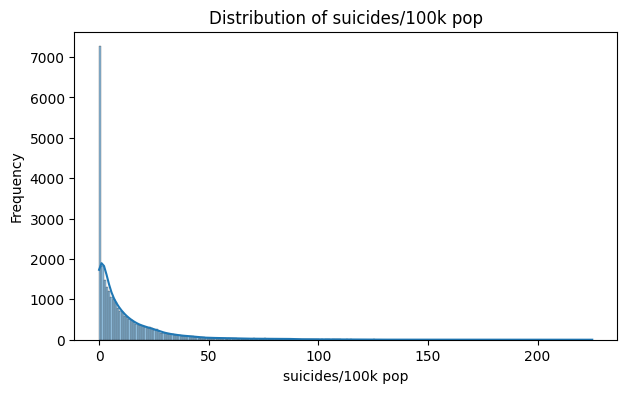

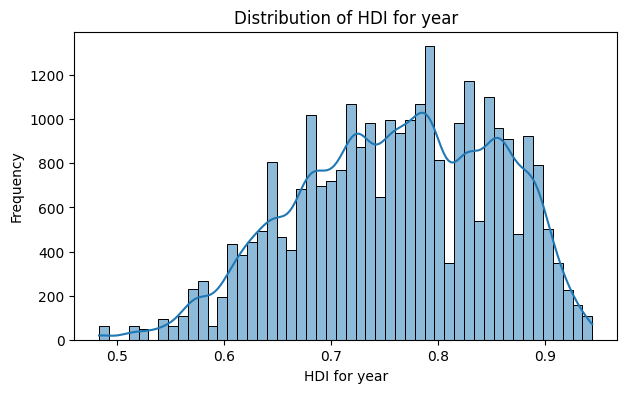

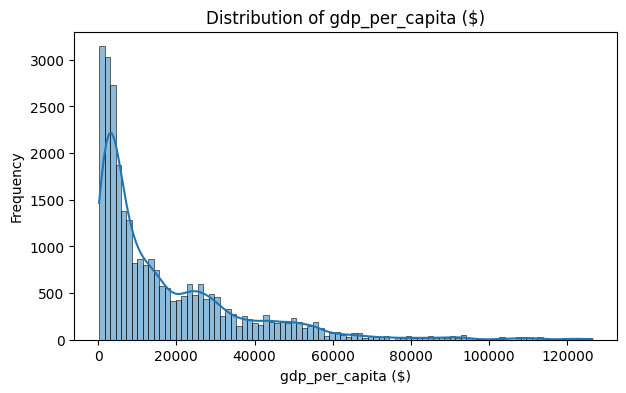

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

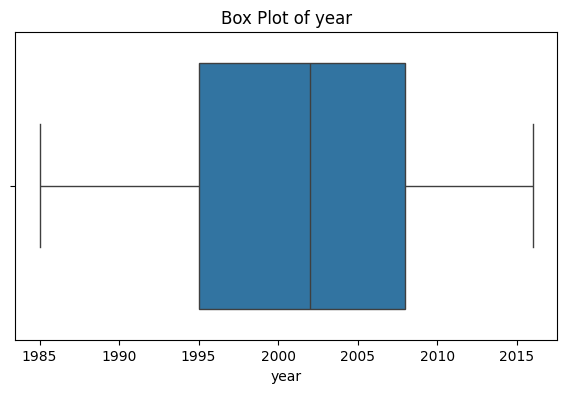

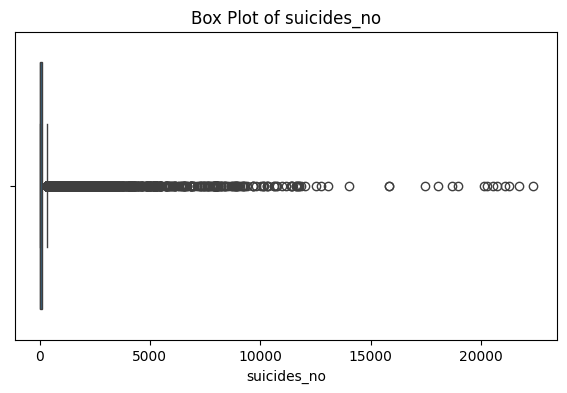

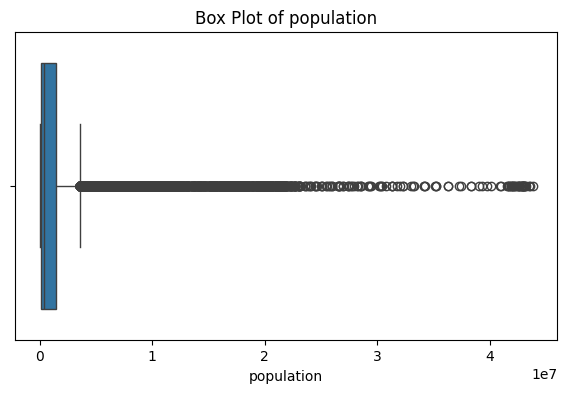

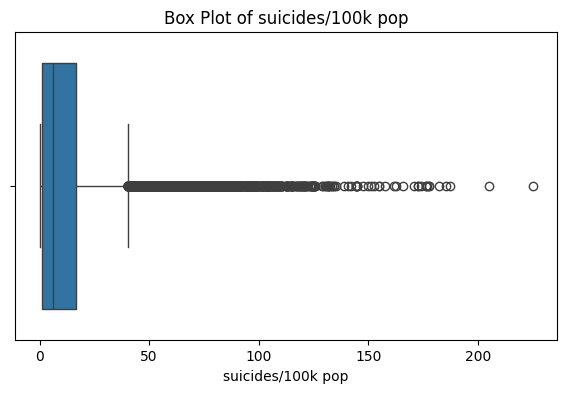

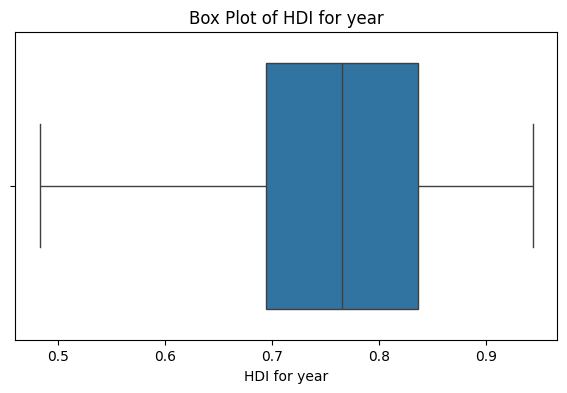

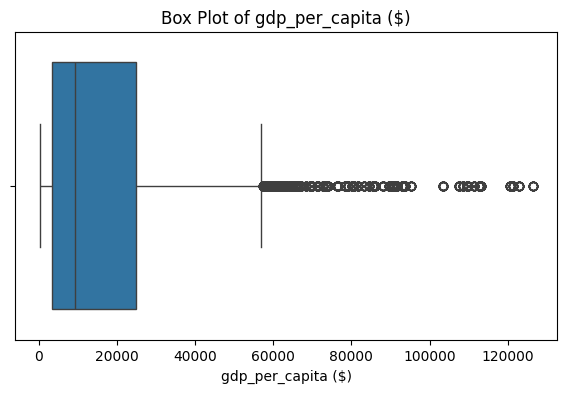

In [23]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title("Box Plot of " + col)
    plt.show()

In [24]:
## 2D Statistical Analysis

In [25]:
corr = df[numeric_cols].corr()
print(corr)

                        year  suicides_no  population  suicides/100k pop  \
year                1.000000    -0.004546    0.008850          -0.039037   
suicides_no        -0.004546     1.000000    0.616162           0.306604   
population          0.008850     0.616162    1.000000           0.008285   
suicides/100k pop  -0.039037     0.306604    0.008285           1.000000   
HDI for year        0.304311     0.120720    0.101851           0.061315   
gdp_per_capita ($)  0.339134     0.061330    0.081510           0.001785   

                    HDI for year  gdp_per_capita ($)  
year                    0.304311            0.339134  
suicides_no             0.120720            0.061330  
population              0.101851            0.081510  
suicides/100k pop       0.061315            0.001785  
HDI for year            1.000000            0.694933  
gdp_per_capita ($)      0.694933            1.000000  


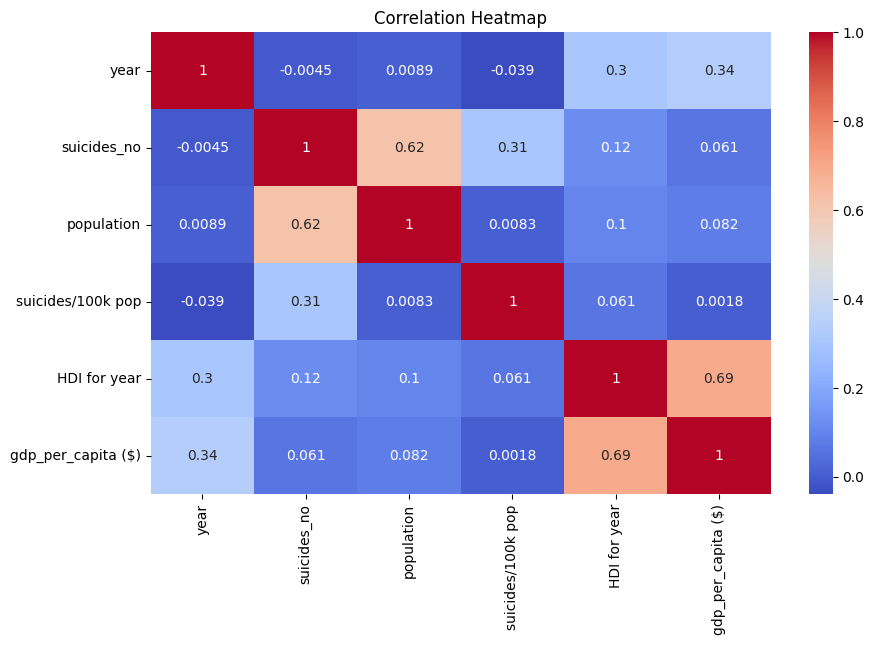

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

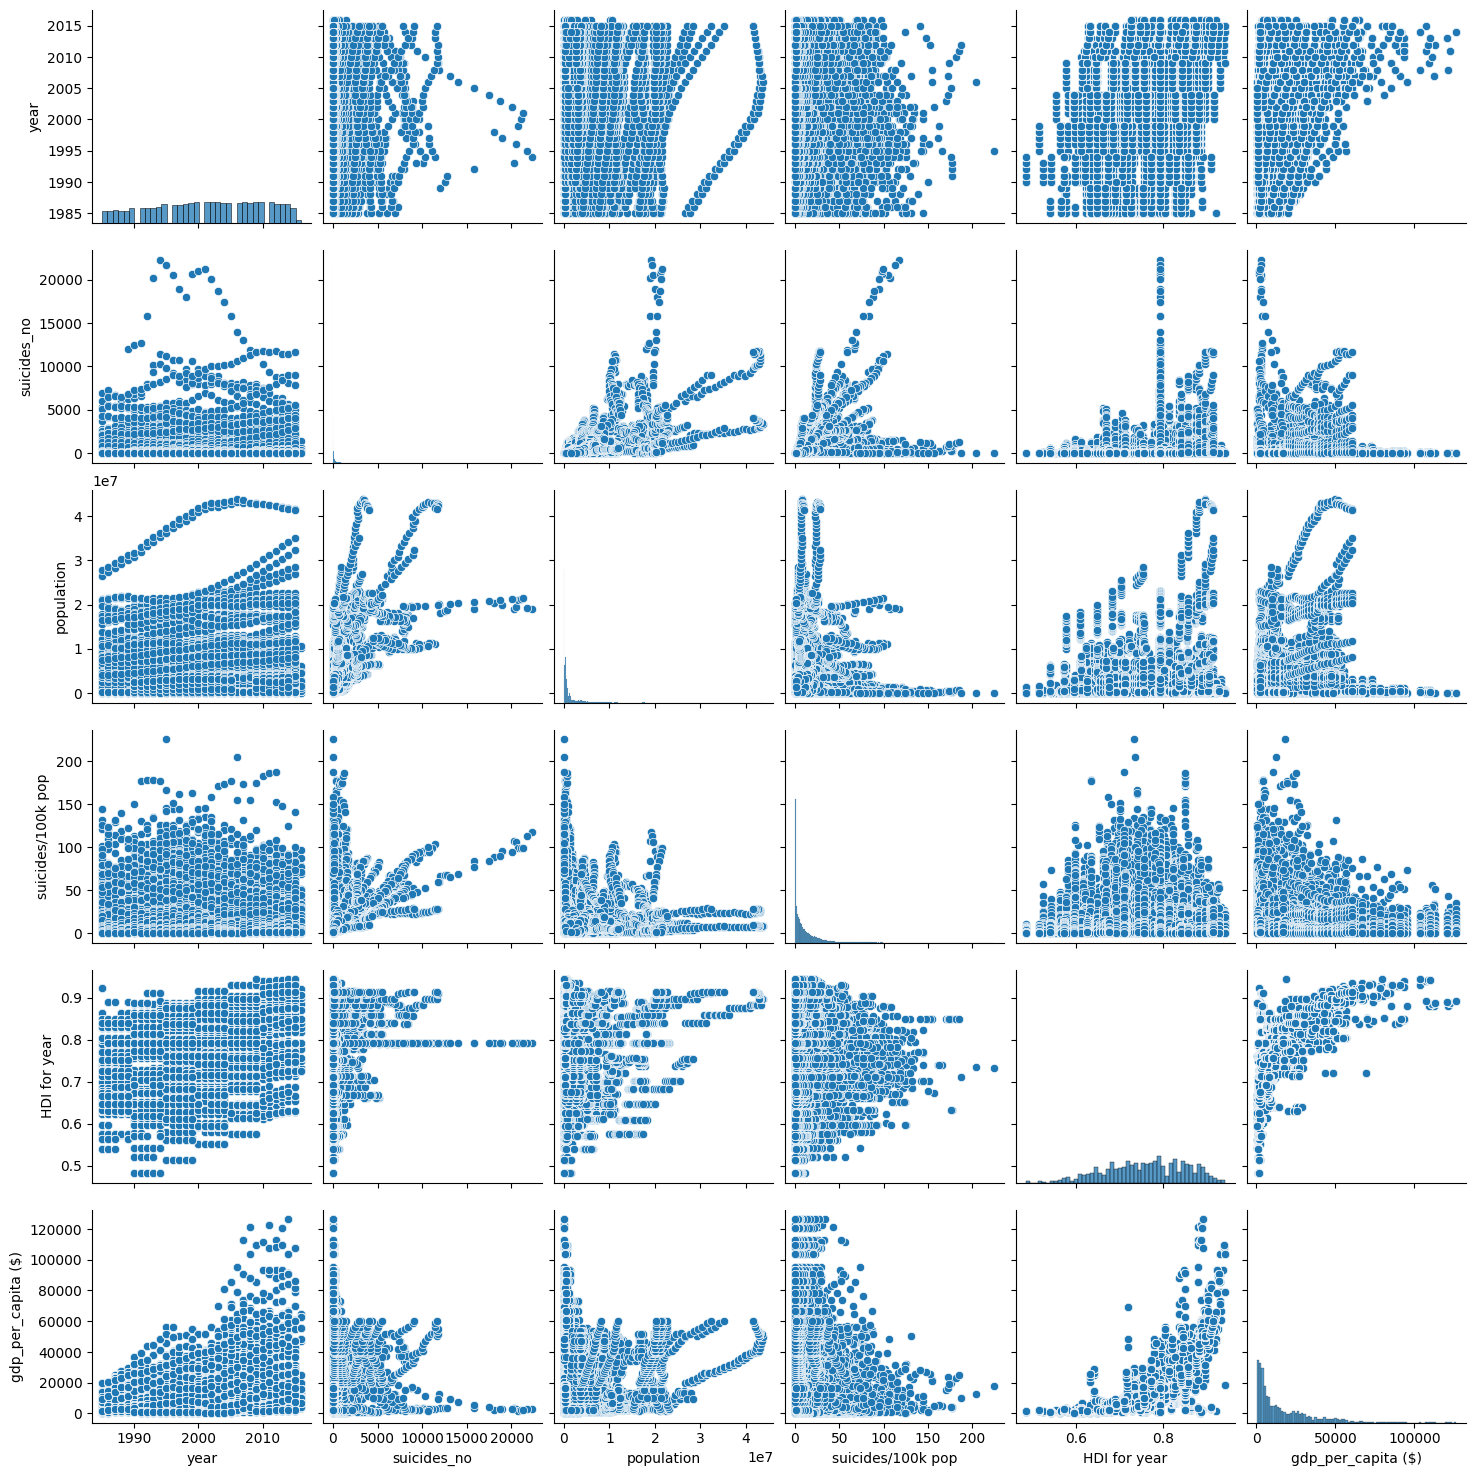

In [27]:
sns.pairplot(df[numeric_cols].dropna())
plt.show()

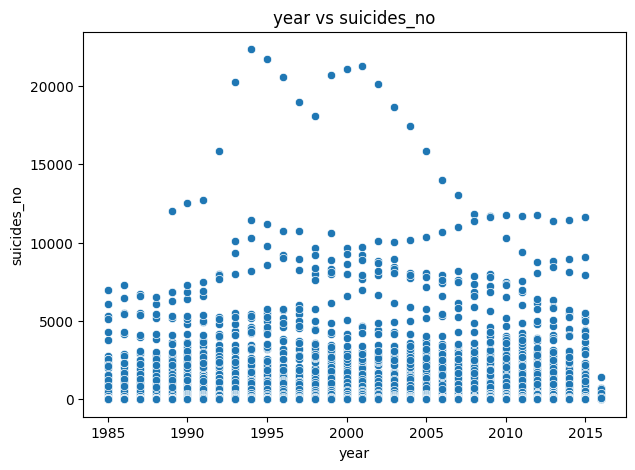

In [28]:
if len(numeric_cols) >= 2:
    x = numeric_cols[0]
    y = numeric_cols[1]

    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

In [29]:
## 3D Statistical Analysis

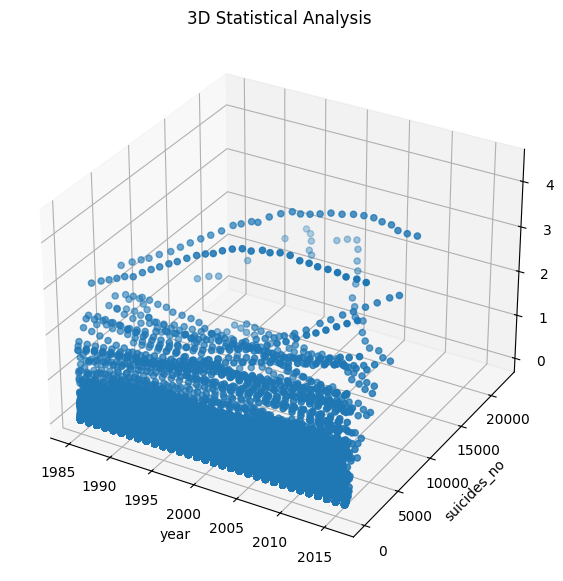

In [30]:
from mpl_toolkits.mplot3d import Axes3D

if len(numeric_cols) >= 3:
    x = numeric_cols[0]
    y = numeric_cols[1]
    z = numeric_cols[2]

    data3d = df[[x, y, z]].dropna()

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        data3d[x],
        data3d[y],
        data3d[z]
    )

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)
    ax.set_title("3D Statistical Analysis")

    plt.show()

In [31]:
## K-Means Clustering

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [33]:
cluster_data = df[numeric_cols].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

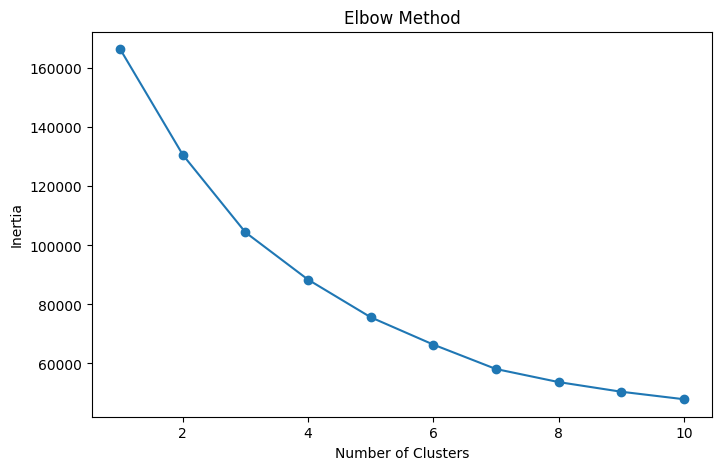

In [34]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data["KMeans_Cluster"] = kmeans.fit_predict(scaled_data)

print(cluster_data.head())

    year  suicides_no  population  suicides/100k pop  HDI for year  \
72  1995           13      232900               5.58         0.619   
73  1995            9      178000               5.06         0.619   
74  1995            2       40800               4.90         0.619   
75  1995           13      283500               4.59         0.619   
76  1995           11      241200               4.56         0.619   

    gdp_per_capita ($)  KMeans_Cluster  
72                 835               2  
73                 835               2  
74                 835               2  
75                 835               2  
76                 835               2  


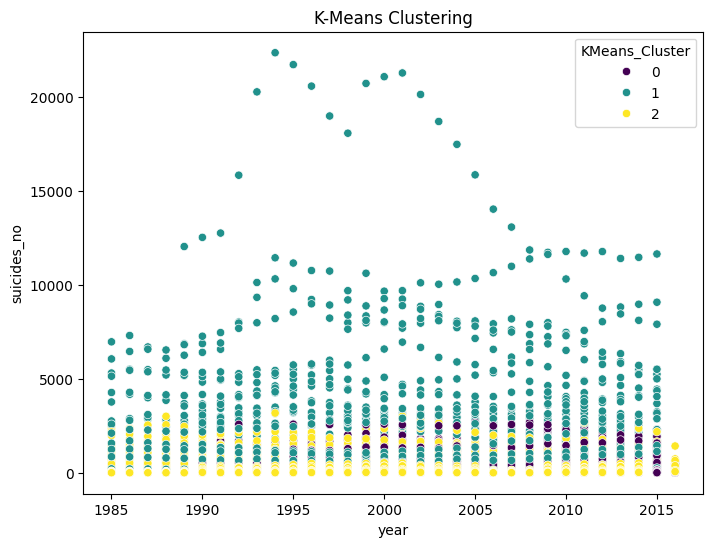

In [36]:
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=cluster_data[numeric_cols[0]],
        y=cluster_data[numeric_cols[1]],
        hue=cluster_data["KMeans_Cluster"],
        palette="viridis"
    )
    plt.title("K-Means Clustering")
    plt.show()

In [37]:
## Hierarchical Clustering

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

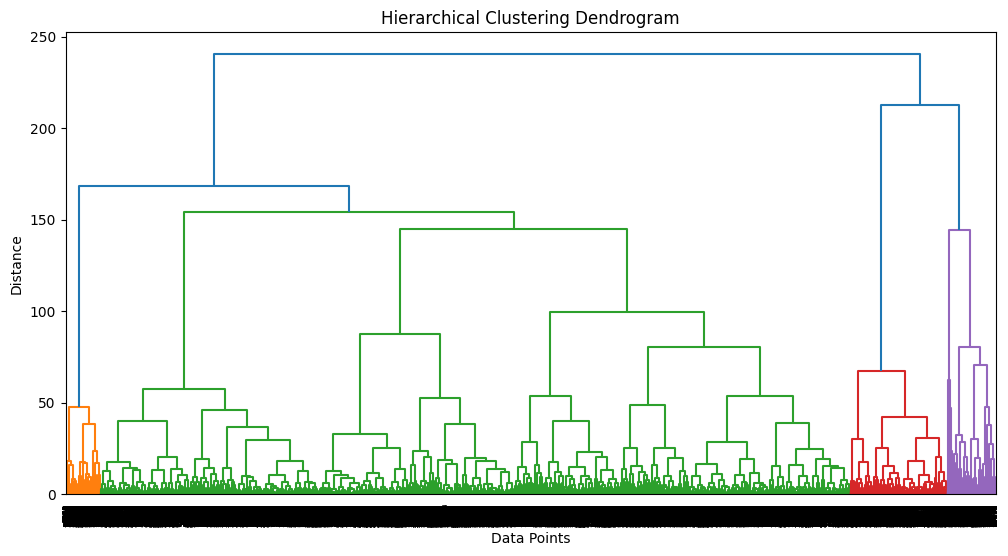

In [41]:
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [39]:
hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(scaled_data)

cluster_data["Hierarchical_Cluster"] = hierarchical_labels

print(cluster_data.head())

    year  suicides_no  population  suicides/100k pop  HDI for year  \
72  1995           13      232900               5.58         0.619   
73  1995            9      178000               5.06         0.619   
74  1995            2       40800               4.90         0.619   
75  1995           13      283500               4.59         0.619   
76  1995           11      241200               4.56         0.619   

    gdp_per_capita ($)  KMeans_Cluster  Hierarchical_Cluster  
72                 835               2                     0  
73                 835               2                     0  
74                 835               2                     0  
75                 835               2                     0  
76                 835               2                     0  


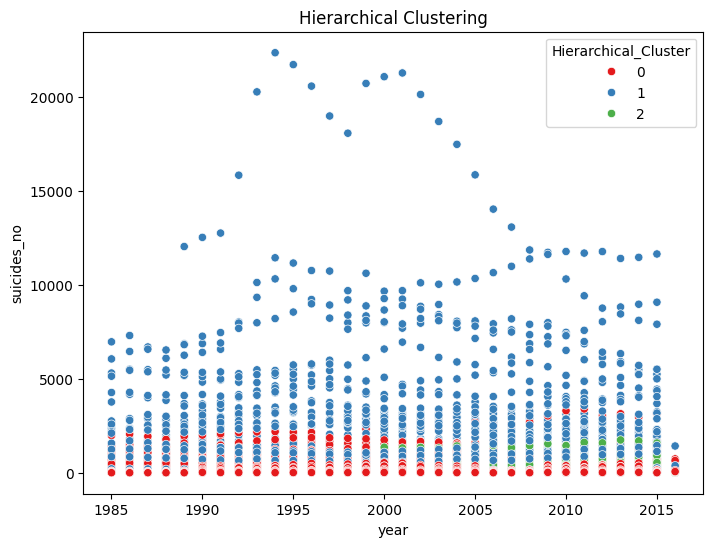

In [40]:
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=cluster_data[numeric_cols[0]],
        y=cluster_data[numeric_cols[1]],
        hue=cluster_data["Hierarchical_Cluster"],
        palette="Set1"
    )
    plt.title("Hierarchical Clustering")
    plt.show()